In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv("Zoo.csv")

data.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [3]:
data = data.drop("animal name", axis=1)

In [4]:
data.isnull().sum()

hair        0
feathers    0
eggs        0
milk        0
airborne    0
aquatic     0
predator    0
toothed     0
backbone    0
breathes    0
venomous    0
fins        0
legs        0
tail        0
domestic    0
catsize     0
type        0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(42)

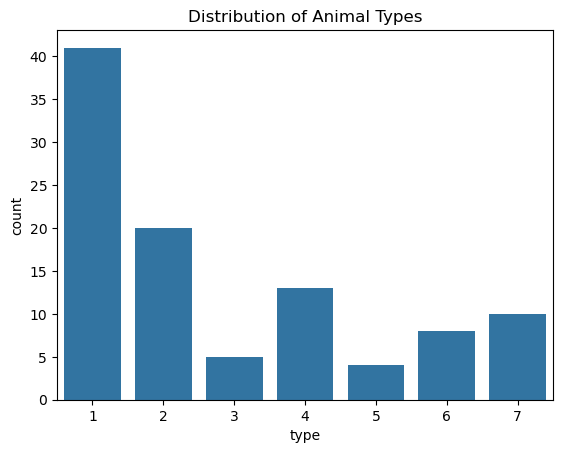

In [6]:
sns.countplot(x="type", data=data)
plt.title("Distribution of Animal Types")
plt.show()

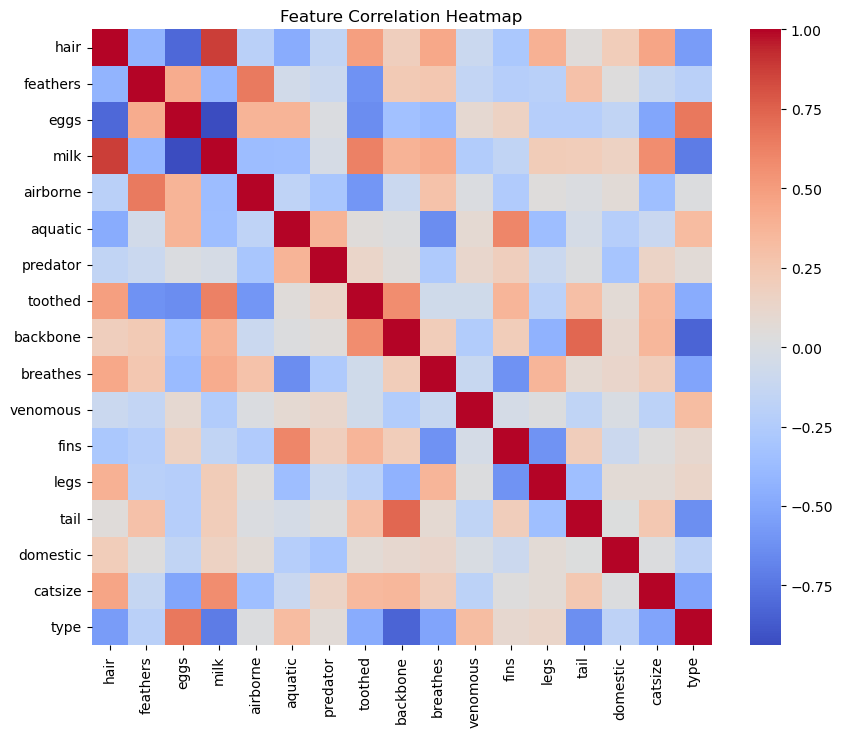

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
X = data.drop("type", axis=1)

y = data["type"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [12]:
y_pred = knn.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9523809523809523


In [15]:
import warnings
warnings.filterwarnings('ignore')
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



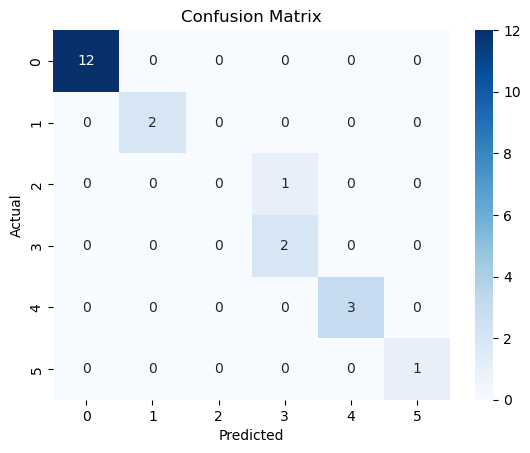

In [16]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

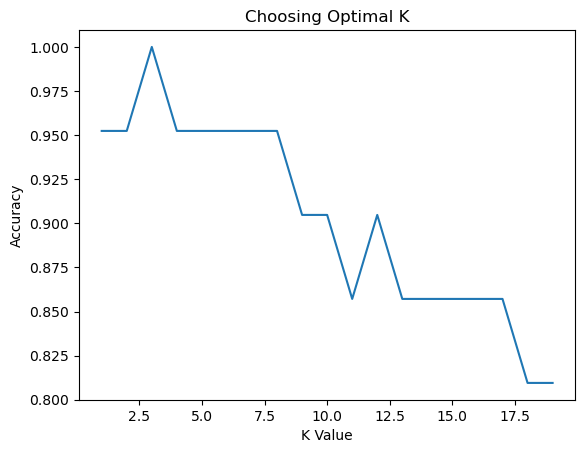

In [17]:
accuracy_list = []

for k in range(1, 20):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy_list.append(accuracy_score(y_test, pred))

plt.plot(range(1,20), accuracy_list)

plt.xlabel("K Value")

plt.ylabel("Accuracy")

plt.title("Choosing Optimal K")

plt.show()

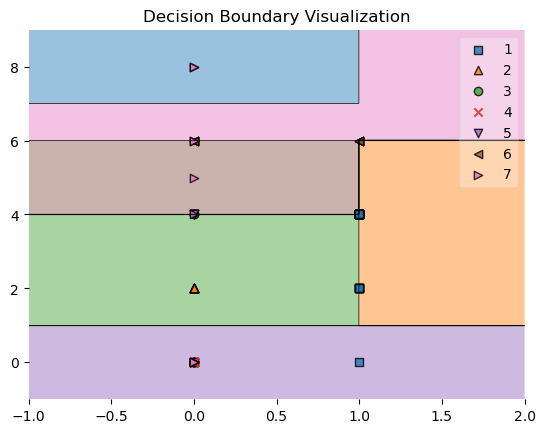

In [18]:
from mlxtend.plotting import plot_decision_regions

X_vis = data[["hair","legs"]].values
y_vis = data["type"].values

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_vis, y_vis)

plot_decision_regions(X_vis, y_vis, clf=model)

plt.title("Decision Boundary Visualization")

plt.show()

Conclusion

Example:

The K-Nearest Neighbors algorithm was applied to classify animals based on their characteristics. The dataset was preprocessed, split into training and testing sets, and the model was trained using KNN with Euclidean distance. The classifier achieved good accuracy and was evaluated using precision, recall, and F1-score. Decision boundaries were visualized to understand the classification behaviour of the model.

Interview Questions
1️⃣ What are the key hyperparameters in KNN?

The main hyperparameters in KNN are:

K (number of neighbors) – determines how many neighbors influence the prediction.

Distance metric – method used to measure similarity between data points.

Weights – determines whether neighbors contribute equally or based on distance.

2️⃣ What distance metrics can be used in KNN?

Common distance metrics include:

Euclidean Distance

Manhattan Distance

Minkowski Distance

Hamming Distance

Cosine Distance

Euclidean distance is the most commonly used metric.